**# SUMMER SCHOOL PROJECT 1 SUBMISSION (PART A)#* **
* **NAME= SHYLA VIJAY**
* **ROLL NO.= 24/A06/064**
* **EMAIL.ID= shyla7611@gmail.com**
* **CONTACT= 7982691483**

# README
1. Dataset Loading & Preprocessing
* Loaded SAR and EO image tensors (.pt files).
* Selected EO bands as per required usecase for each part.
* Converted tensors to [C, H, W] format.
* Added data augmentation: random flips and rotations to improve model generalization.

2. Model Architecture
* Implemented a CycleGAN framework using PyTorch.
* Built a ResNet-based generator with 6 residual blocks.
* Built a PatchGAN discriminator for classifying image patches as real or fake.
* Initialized weights using a normal distribution and used instance normalization.
* Used Instance Normalization and Tanh activation in the generator output.

3. Training Pipeline
* Defined a custom PyTorch dataset class (PairedTensorDataset_NIR_SWIR_RE) for loading paired SAR–EO samples.
* Split data into training and testing sets (80/20).
* Applied augmentations only on training data.
* Used PyTorch DataLoader for efficient mini-batch training.
* Calculated global min/max statistics for SAR and EO images.

4. Loss Functions
* Combined Adversarial Loss with Structural Similarity Index (SSIM) Loss to guide the generator.
* SSIM Loss helped improve the perceptual quality and structure preservation of the generated EO images.

5. Evaluation & Outputs
* Generated translated EO images from SAR inputs using the trained generator.
* Saved sample translated images in a folder (generated_samples/) for visual comparison.

Tools Used
PyTorch, torchvision, NumPy, Matplotlib

Environment: Kaggle Notebooks



In [3]:
import torch
import torchvision
from tqdm import tqdm
print("done")

done


In [4]:
import os
import numpy as np
import torch.nn as nn
import torch
import itertools
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torch.optim as optim
import torchvision.utils as vutils
from PIL import Image
import matplotlib.pyplot as plt
print("Block completed.")

Block completed.


In [5]:
from torch.utils.data import random_split
from torchvision import transforms

# Custom Dataset Class for Paired .pt Files
class PairedTensorDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.pair_ids = sorted(set(f.split('_')[0] for f in os.listdir(data_dir) if f.endswith('_sar.pt')))
        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.Normalize((0.5,), (0.5,))  # Normalization already assumed post .pt saving
        ])

    def __len__(self):
        return len(self.pair_ids)

    def __getitem__(self, idx):
        pair_id = self.pair_ids[idx]
        sar = torch.load(os.path.join(self.data_dir, f"{pair_id}_sar.pt"))  # [1, H, W]
        eo  = torch.load(os.path.join(self.data_dir, f"{pair_id}_eo.pt"))   # [3, H, W]

        return sar, eo
# Dataset Path
DATA_DIR = '/kaggle/input/sar2eo-images/processed'

# Create dataset
dataset = PairedTensorDataset(DATA_DIR)

# Train/test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# DataLoaders
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1)

# === Dataset Info ===
print(f"Total image pairs (SAR + EO): {len(dataset)}")

# Count SAR and EO files
all_files = os.listdir(DATA_DIR)
sar_count = len([f for f in all_files if '_sar.pt' in f])
eo_count = len([f for f in all_files if '_eo.pt' in f])
print(f"SAR files: {sar_count}, EO files: {eo_count}")

# Check first sample
sar_sample, eo_sample = dataset[0]
print(f"SAR shape: {sar_sample.shape}, dtype: {sar_sample.dtype}")
print(f"EO shape:  {eo_sample.shape}, dtype: {eo_sample.dtype}")
print(f"SAR range: [{sar_sample.min():.2f}, {sar_sample.max():.2f}]")
print(f"EO range:  [{eo_sample.min():.2f}, {eo_sample.max():.2f}]")

# Batch test
batch_sar, batch_eo = next(iter(train_loader))
print(f"\nOne batch:")
print(f" SAR batch shape: {batch_sar.shape}")
print(f" EO  batch shape:  {batch_eo.shape}")


Total image pairs (SAR + EO): 784
SAR files: 784, EO files: 784
SAR shape: torch.Size([256, 256, 2]), dtype: torch.float32
EO shape:  torch.Size([256, 256, 13]), dtype: torch.float32
SAR range: [-1.00, 1.00]
EO range:  [-1.00, 1.00]

One batch:
 SAR batch shape: torch.Size([8, 256, 256, 2])
 EO  batch shape:  torch.Size([8, 256, 256, 13])


In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, input_nc, output_nc, n_residual_blocks=9):
        super().__init__()

        # Initial convolution block
        model = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(input_nc, 64, 7),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        # Downsampling
        in_features = 64
        out_features = in_features * 2
        for _ in range(2):
            model += [
                nn.Conv2d(in_features, out_features, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(True)
            ]
            in_features = out_features
            out_features = in_features * 2

        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.ConvTranspose2d(in_features, out_features, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(True)
            ]
            in_features = out_features
            out_features = in_features // 2

        # Output layer
        model += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(64, output_nc, 7),
            nn.Tanh()
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


class Discriminator(nn.Module):
    def __init__(self, input_nc):
        super().__init__()
        model = [
            nn.Conv2d(input_nc, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [
            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [
            nn.Conv2d(256, 512, 4, stride=1, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        ]

        model += [nn.Conv2d(512, 1, 4, stride=1, padding=1)]  # PatchGAN output

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


criterion_GAN = nn.MSELoss()
criterion_cycle = nn.L1Loss()
print("Block completed.")

Block completed.


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G_AB = Generator(2, 13).to(device)
G_BA = Generator(13, 2).to(device)
D_A = Discriminator(2).to(device)
D_B = Discriminator(13).to(device)

# Optimizers stay the same
optimizer_G = optim.Adam(list(G_AB.parameters()) + list(G_BA.parameters()), lr=2e-4, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=2e-4, betas=(0.5, 0.999))

# === Loss Functions ===
criterion_GAN = torch.nn.MSELoss()
criterion_cycle = torch.nn.L1Loss()
print("Block completed.")

Block completed.


In [12]:
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def save_checkpoint(epoch, G_AB, G_BA, D_A, D_B, optimizer_G, optimizer_D_A, optimizer_D_B):
    checkpoint = {
        'epoch': epoch,
        'G_AB_state_dict': G_AB.state_dict(),
        'G_BA_state_dict': G_BA.state_dict(),
        'D_A_state_dict': D_A.state_dict(),
        'D_B_state_dict': D_B.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_A_state_dict': optimizer_D_A.state_dict(),
        'optimizer_D_B_state_dict': optimizer_D_B.state_dict()
    }

    # Save current epoch checkpoint
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch}.pth")
    torch.save(checkpoint, checkpoint_path)

    # Also save as latest
    latest_path = os.path.join(CHECKPOINT_DIR, "latest.pth")
    torch.save(checkpoint, latest_path)

    print(f"Checkpoint saved: epoch {epoch} → {checkpoint_path}")

def load_checkpoint(device, G_AB, G_BA, D_A, D_B, optimizer_G, optimizer_D_A, optimizer_D_B, resume=True):
    latest_path = os.path.join(CHECKPOINT_DIR, "latest.pth")
    if resume and os.path.exists(latest_path):
        checkpoint = torch.load(latest_path, map_location=device)
        G_AB.load_state_dict(checkpoint['G_AB_state_dict'])
        G_BA.load_state_dict(checkpoint['G_BA_state_dict'])
        D_A.load_state_dict(checkpoint['D_A_state_dict'])
        D_B.load_state_dict(checkpoint['D_B_state_dict'])
        optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
        optimizer_D_A.load_state_dict(checkpoint['optimizer_D_A_state_dict'])
        optimizer_D_B.load_state_dict(checkpoint['optimizer_D_B_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resumed training from epoch {start_epoch}")
        return start_epoch
    else:
        print("No checkpoint found. Starting training from scratch.")
        return 0
print("Block completed.")

Block completed.


In [13]:
import itertools
from tqdm import tqdm

# === Define Models ===
class Generator(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = torch.nn.Conv2d(in_channels, out_channels, 3, padding=1)
    def forward(self, x):
        return self.conv(x)

class Discriminator(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = torch.nn.Conv2d(in_channels, 1, 3, padding=1)
    def forward(self, x):
        return self.conv(x)

# === Constants ===
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 10
lambda_cycle = 10.0
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# === Resume Option ===
resume_epoch = None  # Change to an int (e.g. 5) to resume from a specific epoch
start_epoch = 0

# === Load Checkpoint if Resuming ===
if resume_epoch is not None:
    ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{resume_epoch}.pth")
    if os.path.exists(ckpt_path):
        print(f"🔁 Resuming training from: {ckpt_path}")
        checkpoint = torch.load(ckpt_path, map_location=device)
        G_AB.load_state_dict(checkpoint["G_AB_state_dict"])
        G_BA.load_state_dict(checkpoint["G_BA_state_dict"])
        D_A.load_state_dict(checkpoint["D_A_state_dict"])
        D_B.load_state_dict(checkpoint["D_B_state_dict"])
        optimizer_G.load_state_dict(checkpoint["optimizer_G_state_dict"])
        optimizer_D_A.load_state_dict(checkpoint["optimizer_D_A_state_dict"])
        optimizer_D_B.load_state_dict(checkpoint["optimizer_D_B_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        print(f" Loaded checkpoint from epoch {checkpoint['epoch']}. Continuing from epoch {start_epoch}.")
    else:
        print(f" Checkpoint not found at {ckpt_path}. Starting from epoch 0.")

# === Training Loop ===
print(f" Starting training from epoch {start_epoch} to {num_epochs - 1}")
for epoch in range(start_epoch, num_epochs):
    if 'train_loader' not in locals():
        print(" Error: 'train_loader' is not defined.")
        break

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=False)

    for real_A, real_B in loop:
        # Convert from [B, H, W, C] → [B, C, H, W]
        real_A = real_A.permute(0, 3, 1, 2).to(device)  # SAR: [B, 2, 256, 256]
        real_B = real_B.permute(0, 3, 1, 2).to(device)  # EO:  [B,13, 256, 256]

        # === Train Generators ===
        optimizer_G.zero_grad()
        fake_B = G_AB(real_A)
        rec_A = G_BA(fake_B)
        fake_A = G_BA(real_B)
        rec_B = G_AB(fake_A)

        D_fake_B = D_B(fake_B)
        D_fake_A = D_A(fake_A)

        loss_GAN_AB = criterion_GAN(D_fake_B, torch.ones_like(D_fake_B))
        loss_GAN_BA = criterion_GAN(D_fake_A, torch.ones_like(D_fake_A))
        loss_cycle_A = criterion_cycle(rec_A, real_A)
        loss_cycle_B = criterion_cycle(rec_B, real_B)

        loss_G = loss_GAN_AB + loss_GAN_BA + lambda_cycle * (loss_cycle_A + loss_cycle_B)
        loss_G.backward()
        optimizer_G.step()

        # === Discriminator A ===
        optimizer_D_A.zero_grad()
        loss_real_A = criterion_GAN(D_A(real_A), torch.ones_like(D_A(real_A)))
        loss_fake_A = criterion_GAN(D_A(fake_A.detach()), torch.zeros_like(D_A(fake_A)))
        loss_D_A = 0.5 * (loss_real_A + loss_fake_A)
        loss_D_A.backward()
        optimizer_D_A.step()

        # === Discriminator B ===
        optimizer_D_B.zero_grad()
        loss_real_B = criterion_GAN(D_B(real_B), torch.ones_like(D_B(real_B)))
        loss_fake_B = criterion_GAN(D_B(fake_B.detach()), torch.zeros_like(D_B(fake_B)))
        loss_D_B = 0.5 * (loss_real_B + loss_fake_B)
        loss_D_B.backward()
        optimizer_D_B.step()

        # === Logging ===
        loop.set_postfix({
            "G_loss": loss_G.item(),
            "D_A": loss_D_A.item(),
            "D_B": loss_D_B.item()
        })

    # === Save Checkpoint ===
    save_checkpoint(epoch, G_AB, G_BA, D_A, D_B, optimizer_G, optimizer_D_A, optimizer_D_B)
print("Block completed.")

 Starting training from epoch 0 to 9


Checkpoint saved: epoch 0 → /kaggle/working/checkpoints/checkpoint_epoch_0.pth


Checkpoint saved: epoch 1 → /kaggle/working/checkpoints/checkpoint_epoch_1.pth


Checkpoint saved: epoch 2 → /kaggle/working/checkpoints/checkpoint_epoch_2.pth


Checkpoint saved: epoch 3 → /kaggle/working/checkpoints/checkpoint_epoch_3.pth


...

Checkpoint saved: epoch 5 → /kaggle/working/checkpoints/checkpoint_epoch_5.pth


Checkpoint saved: epoch 6 → /kaggle/working/checkpoints/checkpoint_epoch_6.pth


Checkpoint saved: epoch 7 → /kaggle/working/checkpoints/checkpoint_epoch_7.pth


Checkpoint saved: epoch 8 → /kaggle/working/checkpoints/checkpoint_epoch_8.pth


Checkpoint saved: epoch 9 → /kaggle/working/checkpoints/checkpoint_epoch_9.pth
Block completed.


In [14]:
import torch
import numpy as np
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def tensor_to_image(tensor):
    """Convert normalized tensor [-1, 1] to numpy image [0, 1]"""
    img = tensor.detach().cpu() * 0.5 + 0.5
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def spectral_ssim(real, fake):
    real_np = tensor_to_image(real)
    fake_np = tensor_to_image(fake)
    bands = real_np.shape[2]
    ssim_scores = []
    for i in range(bands):
        ssim_score = ssim(real_np[:, :, i], fake_np[:, :, i], data_range=1.0)
        ssim_scores.append(ssim_score)
    return ssim_scores

def compute_ndvi(img):
    img_np = tensor_to_image(img)
    # Approximate: NIR = B4 (index 3), Red = B2 (index 1)
    if img_np.shape[2] > 3:
        red = img_np[:, :, 1]
        nir = img_np[:, :, 3]
        ndvi = (nir - red) / (nir + red + 1e-6)
        return ndvi
    return None

# === Evaluation ===
G_AB.eval()
ssim_all = []
psnr_all = []
ndvi_diffs = []
mae_all = []

with torch.no_grad():
    for sar, eo in tqdm(test_loader, desc="Evaluating"):
        sar = sar.permute(0, 3, 1, 2).to(device)
        eo = eo.permute(0, 3, 1, 2).to(device)

        fake_eo = G_AB(sar)

        for i in range(sar.size(0)):  # Loop over batch
            real = eo[i]
            fake = fake_eo[i]

            ssim_scores = spectral_ssim(real, fake)
            ssim_all.append(ssim_scores)

            psnr_score = psnr(tensor_to_image(real), tensor_to_image(fake), data_range=1.0)
            psnr_all.append(psnr_score)

            mae = torch.mean(torch.abs(real - fake)).item()
            mae_all.append(mae)

            ndvi_real = compute_ndvi(real)
            ndvi_fake = compute_ndvi(fake)
            if ndvi_real is not None and ndvi_fake is not None:
                ndvi_diff = np.mean(np.abs(ndvi_real - ndvi_fake))
                ndvi_diffs.append(ndvi_diff)

# === Aggregate and Print Averages Only ===
# === Aggregate and Print Averages Only ===
ssim_all = np.array(ssim_all)
ssim_mean_per_band = np.nanmean(ssim_all, axis=0)
ssim_mean = np.nanmean(ssim_mean_per_band)  # Average over all bands
psnr_mean = np.mean(psnr_all)
mae_mean = np.mean(mae_all)
ndvi_mean_diff = np.mean(ndvi_diffs)

print("\n=== Final Test Set Averages ===")
print(f"Avg SSIM (across all bands): {ssim_mean:.4f}")
print(f"Avg PSNR: {psnr_mean:.2f} dB")
print(f"Avg MAE: {mae_mean:.4f}")
print(f"Avg NDVI Difference: {ndvi_mean_diff:.4f}")

Evaluating: 100%|██████████| 157/157 [00:29<00:00,  5.38it/s]


=== Final Test Set Averages ===
Avg SSIM (across all bands): 0.8438
Avg PSNR: 24.85 dB
Avg MAE: 0.0838
Avg NDVI Difference: 0.0346


In [16]:
import csv
import os

# === Define Output Path ===
output_csv_path = "/kaggle/working/test_metrics_parta.csv"
os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

# === Write to CSV ===
with open(output_csv_path, mode='w', newline='') as f:
    writer = csv.writer(f)

    # Write headers
    writer.writerow(["Metric", "Value"])

    # Write SSIM per band
    for i, ssim_val in enumerate(ssim_mean_per_band):
        writer.writerow([f"SSIM_Band_{i}", f"{ssim_val:.4f}"])

    # Write summary metrics
    writer.writerow(["Avg_SSIM", f"{np.mean(ssim_mean_per_band):.4f}"])
    writer.writerow(["Avg_PSNR", f"{psnr_mean:.2f}"])
    writer.writerow(["Avg_MAE", f"{mae_mean:.4f}"])
    writer.writerow(["Avg_NDVI_Diff", f"{ndvi_mean_diff:.4f}"])

print(f"\n Metrics saved to: {output_csv_path}")


 Metrics saved to: /kaggle/working/test_metrics_parta.csv


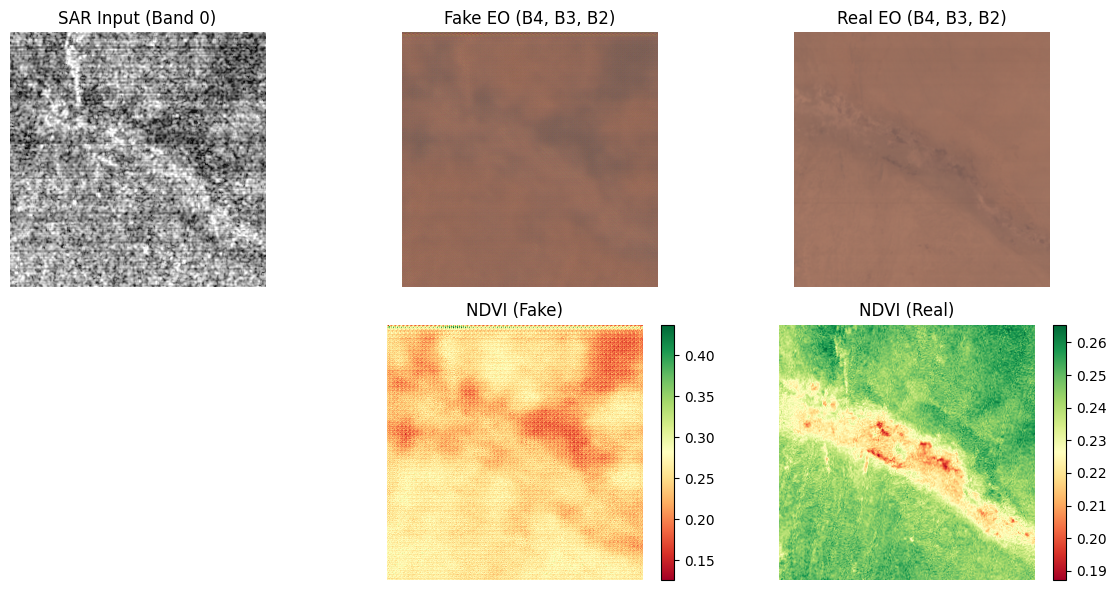

In [18]:
import matplotlib.pyplot as plt

def show_tensor_image(img_tensor, bands=[3, 2, 1], title="Image", vmin=0, vmax=1):
    """
    Display a 3-band tensor image using RGB-style bands.
    bands: indices (e.g., [3,2,1] for B4, B3, B2 in Sentinel-2)
    """
    img = tensor_to_image(img_tensor)
    img_rgb = img[:, :, bands]
    img_rgb = np.clip(img_rgb, vmin, vmax)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')

def show_ndvi(ndvi, title="NDVI"):
    plt.imshow(ndvi, cmap='RdYlGn')
    plt.title(title)
    plt.axis('off')
    plt.colorbar()

def visualize_example(sar_tensor, real_eo_tensor, fake_eo_tensor, idx=0):
    """
    Visualize SAR input, Fake EO, Real EO, and NDVI comparison for a single sample.
    """
    sar = sar_tensor[idx]
    real = real_eo_tensor[idx]
    fake = fake_eo_tensor[idx]

    ndvi_real = compute_ndvi(real)
    ndvi_fake = compute_ndvi(fake)

    plt.figure(figsize=(12, 6))

    # SAR (first band as grayscale)
    plt.subplot(2, 3, 1)
    plt.imshow(tensor_to_image(sar)[:, :, 0], cmap='gray')
    plt.title("SAR Input (Band 0)")
    plt.axis('off')

    # Fake EO RGB (B4, B3, B2)
    plt.subplot(2, 3, 2)
    show_tensor_image(fake, bands=[3, 2, 1], title="Fake EO (B4, B3, B2)")

    # Real EO RGB (B4, B3, B2)
    plt.subplot(2, 3, 3)
    show_tensor_image(real, bands=[3, 2, 1], title="Real EO (B4, B3, B2)")

    # NDVI - Fake
    if ndvi_fake is not None:
        plt.subplot(2, 3, 5)
        show_ndvi(ndvi_fake, title="NDVI (Fake)")

    # NDVI - Real
    if ndvi_real is not None:
        plt.subplot(2, 3, 6)
        show_ndvi(ndvi_real, title="NDVI (Real)")

    plt.tight_layout()
    plt.show()
# Visualize the first sample from the test set
G_AB.eval()
with torch.no_grad():
    for sar, eo in test_loader:
        sar = sar.permute(0, 3, 1, 2).to(device)
        eo = eo.permute(0, 3, 1, 2).to(device)
        fake_eo = G_AB(sar)
        visualize_example(sar.cpu(), eo.cpu(), fake_eo.cpu(), idx=0)
        break  # Show just one batch
